# Modeling

The goal of modeling is to build a model that predicts whether a student is a high performer (in the top 25%) based on their characteristics.

The classification algorithms will be used to identify the most important factors influencing student success.

Firstly, a simple Regression model will be used as a base, and afterwards a more advanced Random Forest model to improve the performance. 

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
df = pd.read_csv("../data/cleaned_data.csv")

In [6]:
q3 = df["Exam_Score"].quantile(0.75)

df.loc[:,"High_Performance"] = df["Exam_Score"] >= q3

df["High_Performance"].value_counts()

High_Performance
False    4358
True     2249
Name: count, dtype: int64

In [7]:
X = df.drop(["Exam_Score", "High_Performance"], axis = 1)
y = df["High_Performance"]

In [8]:
X = pd.get_dummies(X, drop_first = True) # one-hot endcoding

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  0.9750378214826021
              precision    recall  f1-score   support

       False       0.97      0.99      0.98       872
        True       0.98      0.95      0.96       450

    accuracy                           0.98      1322
   macro avg       0.98      0.97      0.97      1322
weighted avg       0.98      0.98      0.97      1322



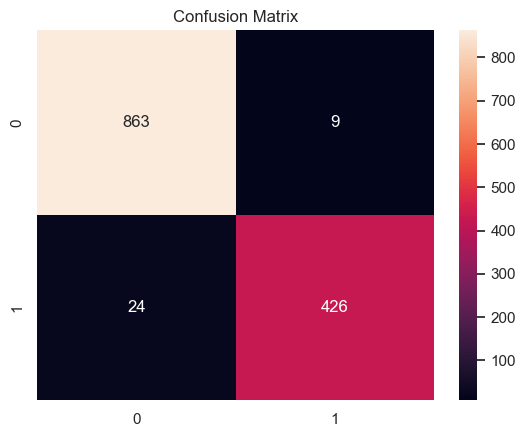

In [25]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt = 'd')
plt.title("Confusion Matrix")
plt.show()

The Logistic Regression model achieved an accuracy of 97.5%, indicating very strong predictive performance.

The confusion matrix shows that the model correctly classifies the vast majority of students. Only 9 low-performing student were misclassified as high performers. Slightly more errors occur when predicting high-performing students, but overall performance still remains very strong.

Both precision and recall score are close to 1, meaning that the model is well-balanced and performs consistantly across both classes.    

---

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy:  0.8956127080181543


In [28]:
feature_importance = pd.Series(rf.feature_importances_, index =X.columns)
feature_importance.sort_values(ascending=False).head(10)

Attendance                     0.368169
Hours_Studied                  0.188917
Previous_Scores                0.083774
Tutoring_Sessions              0.039677
Sleep_Hours                    0.036509
Physical_Activity              0.028658
Access_to_Resources_Low        0.018225
Parental_Involvement_Low       0.016694
Access_to_Resources_Medium     0.014177
Parental_Involvement_Medium    0.013901
dtype: float64

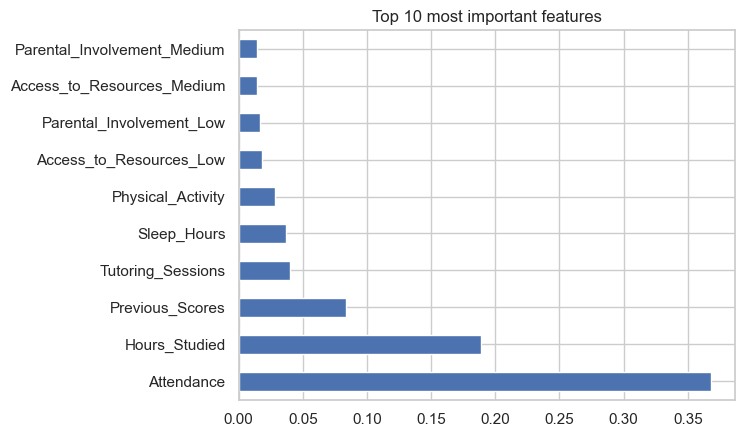

In [29]:
feature_importance.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 most important features")
plt.show()

The two models were evaluated: Logistic Regression and Random Forest. 
Logistic Regression achieved higher accuracy (~97.5%), than Random Forest (~89.6%).

This suggest that the relationships in the dataset are relatively simple and can be effectively captured by linear model and does not require a coplex non-linear modeling of Random Forest.


The Random Forest model highlights the most important factors influencing student performance. 

Attendance is by far the most important factor, with a significantly higher importance score than other variables. Hours Studied is the second most important factor, confirming that study effort plays a key role. Previous score also contribute, although this may also partially reflect information overlap with the target variable.


---


# Summary

The modeling reults confirm the findings from the exploratory data analysis.

Academic engagement, particularly attendance and study time, plays the most significant role in student performance. While other factors contribute, their impact is relatively smaller. 

Interestingly, a simple linear model outperformed a more complex one, suggesting that the relationships between the variables are relatively straightforward.